# Multimodal Retrieval-Augmented Generation System

Unified retrieval across text, code, and images with hybrid retrieval, reranking, and evaluation-driven design.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from config.settings import Config

Config.DATASET = 'main'

## Data Processing

Chunking splits long documents and code into retrieval-friendly units while preserving section/function context.

In [3]:
from pathlib import Path
from time import perf_counter

from chunking.text_chunker import chunk_text_file
from chunking.code_chunker import split_code_by_functions
from config.settings import get_path

data_root = Path(get_path('data'))
text_dir = data_root / 'raw' / 'text'
code_dir = data_root / 'raw' / 'code'
processed_dir = data_root / 'processed'
chunked_text_file = processed_dir / 'chunked_text.json'
chunked_code_file = processed_dir / 'chunked_code.json'

start = perf_counter()

if chunked_text_file.exists() and chunked_code_file.exists():
    print('Chunking skipped: processed chunk files already exist.')
else:
    if text_dir.exists() and not chunked_text_file.exists():
        for text_file in sorted(text_dir.glob('*.txt')):
            chunk_text_file(text_file)

    if code_dir.exists() and not chunked_code_file.exists():
        for code_file in sorted(code_dir.glob('*.py')):
            split_code_by_functions(code_file)

print(f'Chunking time: {perf_counter() - start:.2f}s')

Chunking skipped: processed chunk files already exist.
Chunking time: 0.00s


## Embeddings and Indexing

Embeddings map text/code/images into dense vectors. FAISS indexes those vectors for fast nearest-neighbor retrieval.

In [4]:
import os
from pathlib import Path
from time import perf_counter

import build_and_test_indexes
from config.settings import get_path

os.chdir(PROJECT_ROOT)
index_dir = PROJECT_ROOT / Path(get_path('indexes'))
required_index_files = [
    index_dir / 'faiss_text.index',
    index_dir / 'faiss_text_idmap.json',
    index_dir / 'faiss_code.index',
    index_dir / 'faiss_code_idmap.json',
    index_dir / 'faiss_image.index',
    index_dir / 'faiss_image_idmap.json',
]

start = perf_counter()
if all(p.exists() for p in required_index_files):
    print('Indexing skipped: FAISS index files already exist.')
else:
    build_and_test_indexes.main()

print(f'Indexing time: {perf_counter() - start:.2f}s')

C:\Projects\P2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexing skipped: FAISS index files already exist.
Indexing time: 0.00s


## Evaluation

Evaluation uses standard retrieval metrics:
- Precision@k
- Recall@k
- NDCG
- MRR

In [5]:
import os
from time import perf_counter

import compute_hybrid_metrics
import compute_reranked_metrics
import compute_semantic_metrics

os.chdir(PROJECT_ROOT)
start = perf_counter()

compute_semantic_metrics.main()
compute_hybrid_metrics.main()
compute_reranked_metrics.main()

print(f'Evaluation time: {perf_counter() - start:.2f}s')


Loaded 8 evaluation queries.

Loading FAISS indexes
[FaissIndex] Loaded 66 vector(s) from faiss_text.index  |  faiss_text_idmap.json
[FaissIndex] Loaded 44 vector(s) from faiss_code.index  |  faiss_code_idmap.json
[FaissIndex] Loaded 10 vector(s) from faiss_image.index  |  faiss_image_idmap.json

Loading embedders
[TextEmbedder] Loading 'BAAI/bge-small-en' on cpu ...
[TextEmbedder] Ready. Embedding dim: 384
[CodeEmbedder] Loading 'microsoft/codebert-base' on cpu ...
[CodeEmbedder] Ready. Embedding dim: 768
[ImageEmbedder] Loading 'openai/clip-vit-base-patch32' on cpu ...
[ImageEmbedder] Ready. Embedding dim: 512

Per-query metrics  (P@3 | R@5 | NDCG@5)

  #    Query                                           Mod      P@3    R@5   NDCG@5    GT
1    How does KMeans++ improve centroid initiali...  text   1.000  1.000    1.000     3
2    What is the effect of eps in DBSCAN?            text   1.000  1.000    1.000     3
3    How do you choose the number of clusters in...  text   0.667  0.66

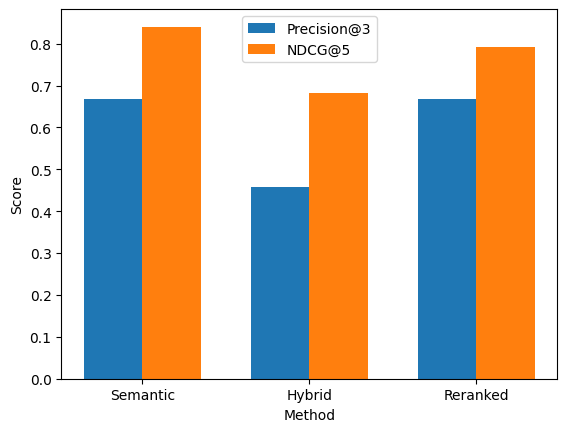

In [6]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['Semantic', 'Hybrid', 'Reranked']
precision_3 = [0.6667, 0.4583, 0.6667]
ndcg_5 = [0.8404, 0.6818, 0.7920]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width / 2, precision_3, width, label='Precision@3')
ax.bar(x + width / 2, ndcg_5, width, label='NDCG@5')
ax.set_xlabel('Method')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
plt.show()

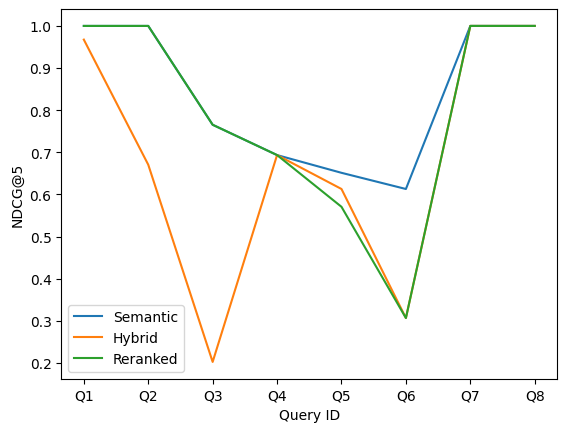

In [7]:
import matplotlib.pyplot as plt

queries = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
semantic_ndcg = [1.0, 1.0, 0.7654, 0.6934, 0.6513, 0.6129, 1.0, 1.0]
hybrid_ndcg = [0.9675, 0.6706, 0.2024, 0.6934, 0.6129, 0.3066, 1.0, 1.0]
reranked_ndcg = [1.0, 1.0, 0.7654, 0.6934, 0.5706, 0.3066, 1.0, 1.0]

fig, ax = plt.subplots()
ax.plot(queries, semantic_ndcg, label='Semantic')
ax.plot(queries, hybrid_ndcg, label='Hybrid')
ax.plot(queries, reranked_ndcg, label='Reranked')
ax.set_xlabel('Query ID')
ax.set_ylabel('NDCG@5')
ax.legend()
plt.show()

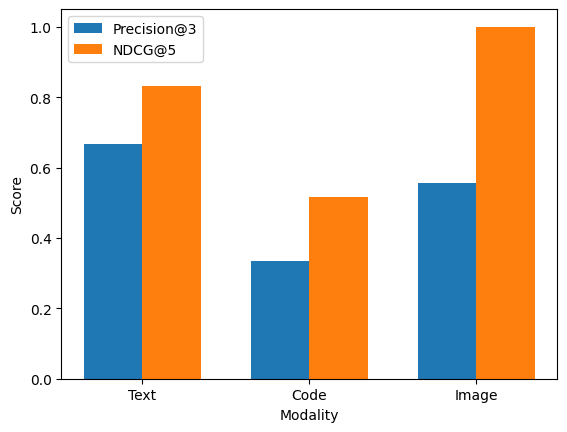

In [8]:
import matplotlib.pyplot as plt
import numpy as np

modalities = ['Text', 'Code', 'Image']
precision_3 = [0.6667, 0.3333, 0.5556]
ndcg_5 = [0.8304, 0.5171, 1.0]

x = np.arange(len(modalities))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width / 2, precision_3, width, label='Precision@3')
ax.bar(x + width / 2, ndcg_5, width, label='NDCG@5')
ax.set_xlabel('Modality')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(modalities)
ax.legend()
plt.show()

## RAG Demo

In [9]:
import pandas as pd

scores = {
    'Precision@3': {'Semantic': 0.6667, 'Hybrid': 0.4583, 'Reranked': 0.6667},
    'Recall@5': {'Semantic': 0.8958, 'Hybrid': 0.7500, 'Reranked': 0.8958},
    'NDCG@5': {'Semantic': 0.8404, 'Hybrid': 0.6818, 'Reranked': 0.7920},
    'MRR': {'Semantic': 0.8750, 'Hybrid': 0.7604, 'Reranked': 0.7708},
}

summary_rows = []
for metric, method_scores in scores.items():
    best_method = max(method_scores, key=method_scores.get)
    best_score = method_scores[best_method]
    summary_rows.append({'Metric': metric, 'Best Method': best_method, 'Score': round(best_score, 4)})

pd.DataFrame(summary_rows)

,Metric,Best Method,Score
0,Precision@3,Semantic,0.6667
1,Recall@5,Semantic,0.8958
2,NDCG@5,Semantic,0.8404
3,MRR,Semantic,0.8750


In [10]:
import io
from contextlib import redirect_stdout

from full_rag_system import FullRAGSystem

with redirect_stdout(io.StringIO()):
    system = FullRAGSystem()

demo_queries = [
    ('Explain DBSCAN eps parameter', 'text'),
    ('Example of DBSCAN eps tuning in Python', 'code'),
    ('ROC curve visualization example', 'image'),
]

for query, modality in demo_queries:
    with redirect_stdout(io.StringIO()):
        result = system.run_query(query, modality)

    print('Query:')
    print(result['query'])
    print()
    print('Answer:')
    print(result['answer'])
    print()
    print('Retrieved Chunk IDs:')
    print(result['sources'])
    print()

Query:
Explain DBSCAN eps parameter

Answer:
EPSILON, MIN_SAMPLES, AND TUNING STRATEGIES DBSCAN exposes a small but powerful set of parameters that directly control the shape, count, and quality of clusters it produces. Understanding how each parameter interacts with data geometry is essential for using DBSCAN effectively in any ML pipeline.

Retrieved Chunk IDs:
['text_009', 'text_000']

Query:
Example of DBSCAN eps tuning in Python

Answer:
### DBSCAN eps tuning in Python

Retrieved Chunk IDs:
['code_006', 'code_000']

Query:
ROC curve visualization example

Answer:
ROC curves

Retrieved Chunk IDs:
['image_008', 'image_003']

